In [20]:
import sys
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "PCB_DATASET"

IMAGE_ROOT = DATASET_ROOT / "Images"
ANNOTATION_ROOT = DATASET_ROOT / "Annotations"
TEMPLATE_ROOT = DATASET_ROOT / "PCB_USED"

defective_path = (
    IMAGE_ROOT
    / "Missing_hole"
    / "01_missing_hole_01.jpg"
)

reference_path = TEMPLATE_ROOT / "01.JPG"

annotation_path = (
    ANNOTATION_ROOT
    / "Missing_hole"
    / "01_missing_hole_01.xml"
)

print("Defective image:", defective_path.exists())
print("Reference image:", reference_path.exists())
print("Annotation:", annotation_path.exists())

Defective image: True
Reference image: True
Annotation: True


In [19]:
reference = cv2.imread(str(reference_path))
defective = cv2.imread(str(defective_path))

if reference is None:
    raise FileNotFoundError(f"Unable to load: {reference_path}")

if defective is None:
    raise FileNotFoundError(f"Unable to load: {defective_path}")

print("Reference shape:", reference.shape)
print("Defective shape:", defective.shape)

Reference shape: (1586, 3034, 3)
Defective shape: (1586, 3034, 3)


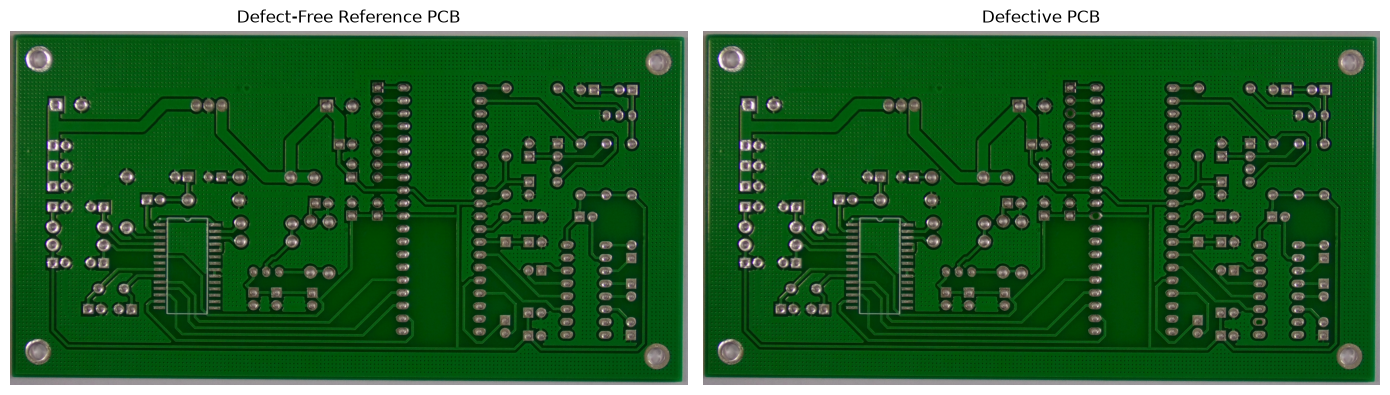

In [22]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(reference, cv2.COLOR_BGR2RGB))
plt.title("Defect-Free Reference PCB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(defective, cv2.COLOR_BGR2RGB))
plt.title("Defective PCB")
plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
height, width = reference.shape[:2]

defective_resized = cv2.resize(
    defective,
    (width, height),
    interpolation=cv2.INTER_AREA
)

reference_gray = cv2.cvtColor(
    reference,
    cv2.COLOR_BGR2GRAY
)

defective_gray = cv2.cvtColor(
    defective_resized,
    cv2.COLOR_BGR2GRAY
)

reference_blur = cv2.GaussianBlur(
    reference_gray,
    (5, 5),
    0
)

defective_blur = cv2.GaussianBlur(
    defective_gray,
    (5, 5),
    0
)

difference = cv2.absdiff(
    reference_blur,
    defective_blur
)

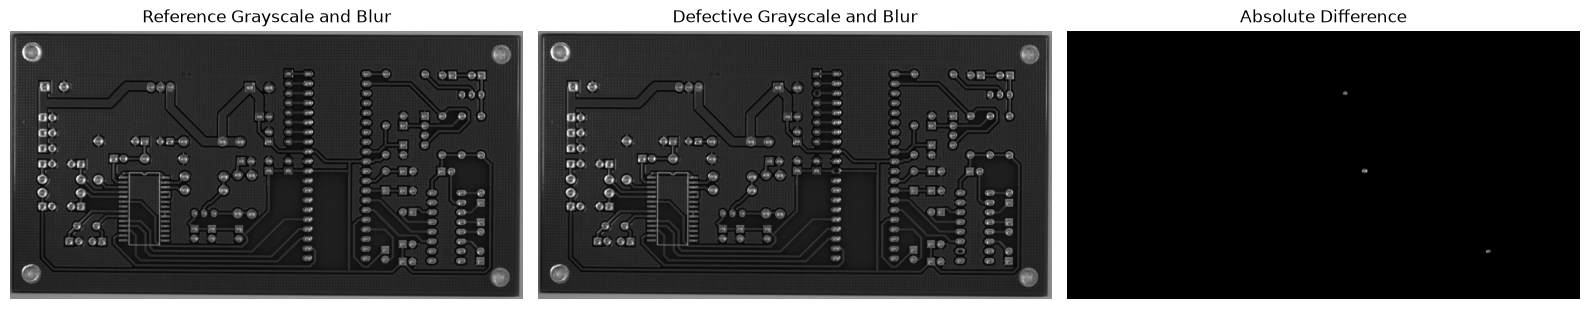

In [24]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(reference_blur, cmap="gray")
plt.title("Reference Grayscale and Blur")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(defective_blur, cmap="gray")
plt.title("Defective Grayscale and Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference, cmap="gray")
plt.title("Absolute Difference")
plt.axis("off")

plt.tight_layout()
plt.show()

Otsu threshold: 43.0
Raw Otsu processing time: 7.682 ms


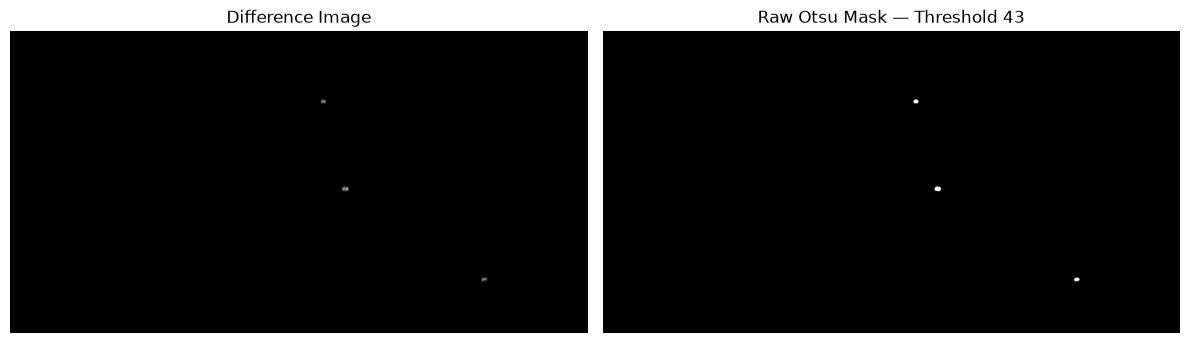

In [26]:
start_time = time.perf_counter()

threshold_value, otsu_mask = cv2.threshold(
    difference,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

raw_otsu_time_ms = (
    time.perf_counter() - start_time
) * 1000

print("Otsu threshold:", threshold_value)
print(f"Raw Otsu processing time: {raw_otsu_time_ms:.3f} ms")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(difference, cmap="gray")
plt.title("Difference Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_mask, cmap="gray")
plt.title(f"Raw Otsu Mask — Threshold {threshold_value:.0f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
white_pixels = cv2.countNonZero(otsu_mask)
total_pixels = otsu_mask.size

white_pixel_percentage = (
    white_pixels / total_pixels
) * 100

print("White pixels:", white_pixels)
print(f"White-pixel percentage: {white_pixel_percentage:.6f}%")

White pixels: 1564
White-pixel percentage: 0.032503%


In [29]:
def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []

    for obj in root.findall("object"):
        bndbox = obj.find("bndbox")

        boxes.append({
            "class": obj.findtext("name"),
            "xmin": int(bndbox.findtext("xmin")),
            "ymin": int(bndbox.findtext("ymin")),
            "xmax": int(bndbox.findtext("xmax")),
            "ymax": int(bndbox.findtext("ymax")),
        })

    return boxes

ground_truth_boxes = parse_annotation(annotation_path)

print("Ground-truth defects:", len(ground_truth_boxes))

for index, box in enumerate(ground_truth_boxes):
    print(f"GT {index}:", box)

Ground-truth defects: 3
GT 0: {'class': 'missing_hole', 'xmin': 2459, 'ymin': 1274, 'xmax': 2530, 'ymax': 1329}
GT 1: {'class': 'missing_hole', 'xmin': 1613, 'ymin': 334, 'xmax': 1679, 'ymax': 396}
GT 2: {'class': 'missing_hole', 'xmin': 1726, 'ymin': 794, 'xmax': 1797, 'ymax': 854}


In [30]:
def extract_predicted_boxes(
    binary_mask,
    minimum_area=20
):
    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []

    for contour in contours:
        contour_area = cv2.contourArea(contour)

        if contour_area < minimum_area:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        boxes.append({
            "xmin": int(x),
            "ymin": int(y),
            "xmax": int(x + w),
            "ymax": int(y + h),
            "contour_area": float(contour_area),
        })

    return boxes

raw_predicted_boxes = extract_predicted_boxes(
    otsu_mask,
    minimum_area=20
)

print("Raw Otsu detected regions:", len(raw_predicted_boxes))

for index, box in enumerate(raw_predicted_boxes):
    print(f"Prediction {index}:", box)

Raw Otsu detected regions: 3
Prediction 0: {'xmin': 2478, 'ymin': 1295, 'xmax': 2506, 'ymax': 1315, 'contour_area': 398.5}
Prediction 1: {'xmin': 1745, 'ymin': 816, 'xmax': 1778, 'ymax': 841, 'contour_area': 630.5}
Prediction 2: {'xmin': 1633, 'ymin': 358, 'xmax': 1660, 'ymax': 380, 'contour_area': 420.5}


In [31]:
def calculate_iou(box_a, box_b):
    intersection_xmin = max(
        box_a["xmin"],
        box_b["xmin"]
    )

    intersection_ymin = max(
        box_a["ymin"],
        box_b["ymin"]
    )

    intersection_xmax = min(
        box_a["xmax"],
        box_b["xmax"]
    )

    intersection_ymax = min(
        box_a["ymax"],
        box_b["ymax"]
    )

    intersection_width = max(
        0,
        intersection_xmax - intersection_xmin
    )

    intersection_height = max(
        0,
        intersection_ymax - intersection_ymin
    )

    intersection_area = (
        intersection_width * intersection_height
    )

    area_a = (
        (box_a["xmax"] - box_a["xmin"])
        * (box_a["ymax"] - box_a["ymin"])
    )

    area_b = (
        (box_b["xmax"] - box_b["xmin"])
        * (box_b["ymax"] - box_b["ymin"])
    )

    union_area = (
        area_a + area_b - intersection_area
    )

    if union_area <= 0:
        return 0.0

    return intersection_area / union_area

def calculate_prediction_coverage(
    prediction,
    ground_truth
):
    intersection_xmin = max(
        prediction["xmin"],
        ground_truth["xmin"]
    )

    intersection_ymin = max(
        prediction["ymin"],
        ground_truth["ymin"]
    )

    intersection_xmax = min(
        prediction["xmax"],
        ground_truth["xmax"]
    )

    intersection_ymax = min(
        prediction["ymax"],
        ground_truth["ymax"]
    )

    intersection_width = max(
        0,
        intersection_xmax - intersection_xmin
    )

    intersection_height = max(
        0,
        intersection_ymax - intersection_ymin
    )

    intersection_area = (
        intersection_width * intersection_height
    )

    prediction_area = (
        (prediction["xmax"] - prediction["xmin"])
        * (prediction["ymax"] - prediction["ymin"])
    )

    if prediction_area <= 0:
        return 0.0

    return intersection_area / prediction_area

def evaluate_predictions(
    predicted_boxes,
    ground_truth_boxes,
    iou_threshold=0.30
):
    matched_predictions = set()
    matched_ground_truth = set()
    matches = []

    candidate_matches = []

    for prediction_index, prediction in enumerate(
        predicted_boxes
    ):
        for ground_truth_index, ground_truth in enumerate(
            ground_truth_boxes
        ):
            iou = calculate_iou(
                prediction,
                ground_truth
            )

            candidate_matches.append({
                "prediction_index": prediction_index,
                "ground_truth_index": ground_truth_index,
                "iou": iou,
            })

    candidate_matches.sort(
        key=lambda item: item["iou"],
        reverse=True
    )

    for candidate in candidate_matches:
        prediction_index = candidate["prediction_index"]
        ground_truth_index = candidate["ground_truth_index"]
        iou = candidate["iou"]

        if iou < iou_threshold:
            continue

        if prediction_index in matched_predictions:
            continue

        if ground_truth_index in matched_ground_truth:
            continue

        matched_predictions.add(prediction_index)
        matched_ground_truth.add(ground_truth_index)

        matches.append(candidate)

    true_positives = len(matches)

    false_positives = (
        len(predicted_boxes) - true_positives
    )

    false_negatives = (
        len(ground_truth_boxes) - true_positives
    )

    precision = (
        true_positives
        / (true_positives + false_positives)
        if true_positives + false_positives > 0
        else 0.0
    )

    recall = (
        true_positives
        / (true_positives + false_negatives)
        if true_positives + false_negatives > 0
        else 0.0
    )

    f1_score = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    mean_iou = (
        np.mean([match["iou"] for match in matches])
        if matches
        else 0.0
    )

    return {
        "iou_threshold": iou_threshold,
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "mean_iou": float(mean_iou),
        "matches": matches,
    }

for prediction_index, prediction in enumerate(
    raw_predicted_boxes
):
    best_iou = 0.0
    best_gt_index = None
    best_coverage = 0.0

    for gt_index, ground_truth in enumerate(
        ground_truth_boxes
    ):
        iou = calculate_iou(
            prediction,
            ground_truth
        )

        coverage = calculate_prediction_coverage(
            prediction,
            ground_truth
        )

        print(
            f"Prediction {prediction_index} vs GT {gt_index}: "
            f"IoU={iou:.4f}, "
            f"prediction coverage={coverage:.4f}"
        )

        if iou > best_iou:
            best_iou = iou
            best_gt_index = gt_index
            best_coverage = coverage

    print(
        f"Best match for prediction {prediction_index}: "
        f"GT {best_gt_index}, "
        f"IoU={best_iou:.4f}, "
        f"coverage={best_coverage:.4f}\n"
    )

Prediction 0 vs GT 0: IoU=0.1434, prediction coverage=1.0000
Prediction 0 vs GT 1: IoU=0.0000, prediction coverage=0.0000
Prediction 0 vs GT 2: IoU=0.0000, prediction coverage=0.0000
Best match for prediction 0: GT 0, IoU=0.1434, coverage=1.0000

Prediction 1 vs GT 0: IoU=0.0000, prediction coverage=0.0000
Prediction 1 vs GT 1: IoU=0.0000, prediction coverage=0.0000
Prediction 1 vs GT 2: IoU=0.1937, prediction coverage=1.0000
Best match for prediction 1: GT 2, IoU=0.1937, coverage=1.0000

Prediction 2 vs GT 0: IoU=0.0000, prediction coverage=0.0000
Prediction 2 vs GT 1: IoU=0.1452, prediction coverage=1.0000
Prediction 2 vs GT 2: IoU=0.0000, prediction coverage=0.0000
Best match for prediction 2: GT 1, IoU=0.1452, coverage=1.0000



In [34]:
raw_metrics_030 = evaluate_predictions(
    raw_predicted_boxes,
    ground_truth_boxes,
    iou_threshold=0.30
)

raw_metrics_030

{'iou_threshold': 0.3,
 'true_positives': 0,
 'false_positives': 3,
 'false_negatives': 3,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'mean_iou': 0.0,
 'matches': []}

In [35]:
raw_metrics_010 = evaluate_predictions(
    raw_predicted_boxes,
    ground_truth_boxes,
    iou_threshold=0.10
)

raw_metrics_010

{'iou_threshold': 0.1,
 'true_positives': 3,
 'false_positives': 0,
 'false_negatives': 0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0,
 'mean_iou': 0.16074305067944325,
 'matches': [{'prediction_index': 1,
   'ground_truth_index': 2,
   'iou': 0.1936619718309859},
  {'prediction_index': 2, 'ground_truth_index': 1, 'iou': 0.14516129032258066},
  {'prediction_index': 0,
   'ground_truth_index': 0,
   'iou': 0.14340588988476313}]}

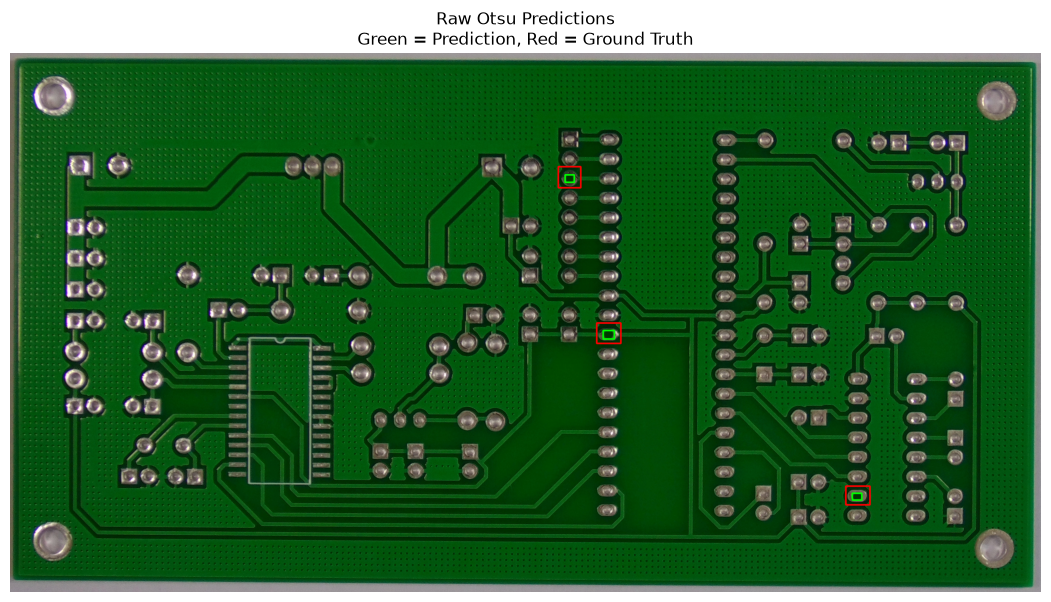

In [37]:
def draw_boxes(
    image,
    predicted_boxes,
    ground_truth_boxes,
    title
):
    output = image.copy()

    for box in predicted_boxes:
        cv2.rectangle(
            output,
            (box["xmin"], box["ymin"]),
            (box["xmax"], box["ymax"]),
            (0, 255, 0),
            3
        )

    for box in ground_truth_boxes:
        cv2.rectangle(
            output,
            (box["xmin"], box["ymin"]),
            (box["xmax"], box["ymax"]),
            (0, 0, 255),
            3
        )

    plt.figure(figsize=(14, 7))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title(
        title
        + "\nGreen = Prediction, Red = Ground Truth"
    )
    plt.axis("off")
    plt.show()

draw_boxes(
    defective_resized,
    raw_predicted_boxes,
    ground_truth_boxes,
    "Raw Otsu Predictions"
)

Morphological refinement time: 29.792 ms


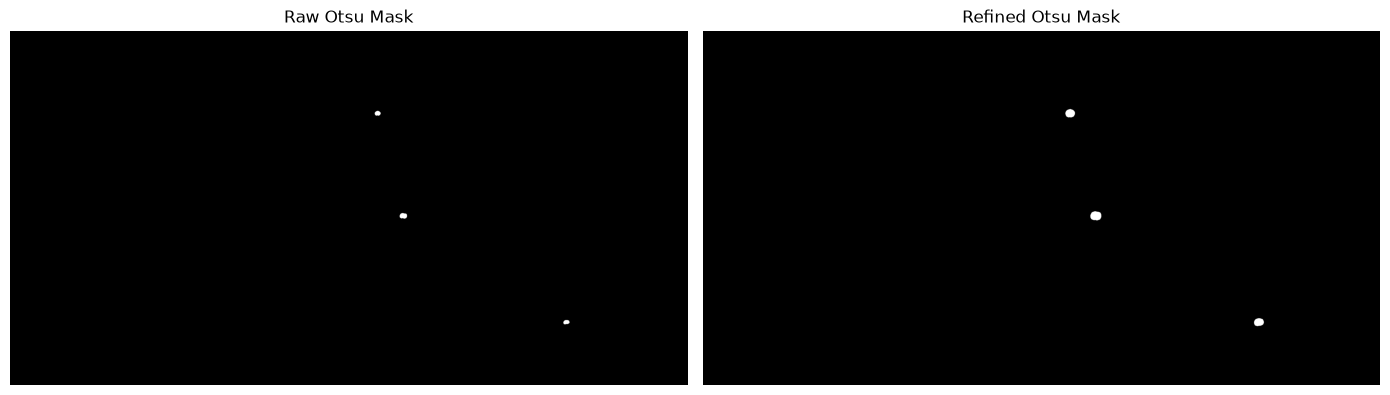

In [38]:
refinement_start = time.perf_counter()

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (9, 9)
)

otsu_closed = cv2.morphologyEx(
    otsu_mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)

otsu_refined = cv2.dilate(
    otsu_closed,
    kernel,
    iterations=2
)

refinement_time_ms = (
    time.perf_counter() - refinement_start
) * 1000

print(
    f"Morphological refinement time: "
    f"{refinement_time_ms:.3f} ms"
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(otsu_mask, cmap="gray")
plt.title("Raw Otsu Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_refined, cmap="gray")
plt.title("Refined Otsu Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Refined Otsu detected regions: 3
Prediction 0: {'xmin': 2470, 'ymin': 1287, 'xmax': 2514, 'ymax': 1323, 'contour_area': 1194.5}
Prediction 1: {'xmin': 1737, 'ymin': 808, 'xmax': 1786, 'ymax': 849, 'contour_area': 1570.5}
Prediction 2: {'xmin': 1625, 'ymin': 350, 'xmax': 1668, 'ymax': 388, 'contour_area': 1224.5}


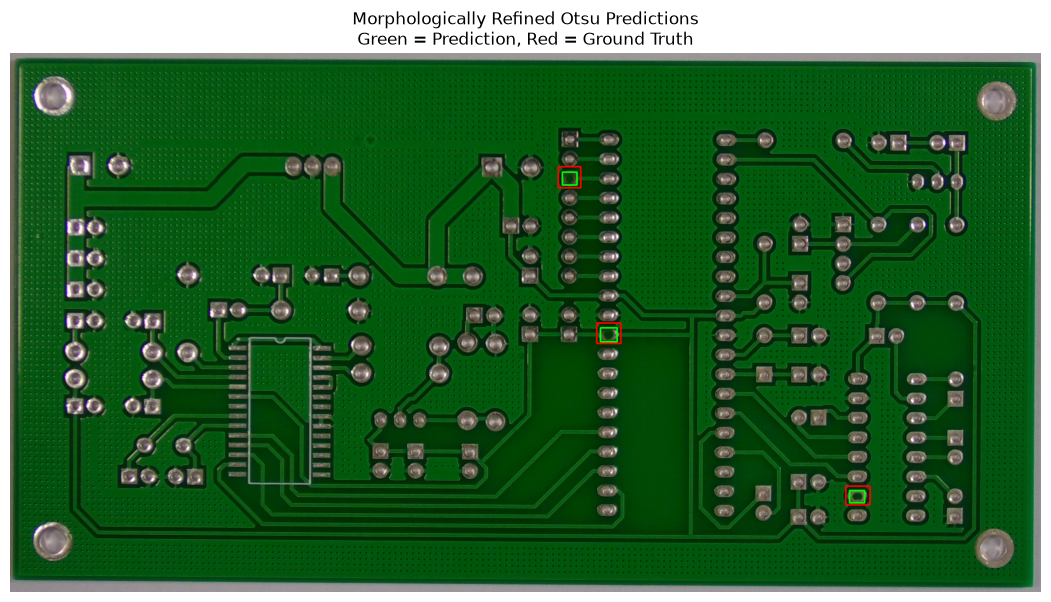

In [39]:
refined_predicted_boxes = extract_predicted_boxes(
    otsu_refined,
    minimum_area=50
)

print(
    "Refined Otsu detected regions:",
    len(refined_predicted_boxes)
)

for index, box in enumerate(refined_predicted_boxes):
    print(f"Prediction {index}:", box)

refined_metrics_030 = evaluate_predictions(
    refined_predicted_boxes,
    ground_truth_boxes,
    iou_threshold=0.30
)

refined_metrics_030

draw_boxes(
    defective_resized,
    refined_predicted_boxes,
    ground_truth_boxes,
    "Morphologically Refined Otsu Predictions"
)

In [42]:
raw_otsu_result = {
    "image_id": defective_path.stem,
    "algorithm": "Raw Otsu",
    "threshold": float(threshold_value),
    "processing_time_ms": float(raw_otsu_time_ms),
    "white_pixel_percentage": float(
        white_pixel_percentage
    ),
    "detected_regions": len(raw_predicted_boxes),
    "iou_threshold": raw_metrics_030[
        "iou_threshold"
    ],
    "true_positives": raw_metrics_030[
        "true_positives"
    ],
    "false_positives": raw_metrics_030[
        "false_positives"
    ],
    "false_negatives": raw_metrics_030[
        "false_negatives"
    ],
    "precision": raw_metrics_030["precision"],
    "recall": raw_metrics_030["recall"],
    "f1_score": raw_metrics_030["f1_score"],
    "mean_iou": raw_metrics_030["mean_iou"],
}

print("Raw Otsu result:")
raw_otsu_result

Raw Otsu result:


{'image_id': '01_missing_hole_01',
 'algorithm': 'Raw Otsu',
 'threshold': 43.0,
 'processing_time_ms': 7.6821000257041305,
 'white_pixel_percentage': 0.03250259147900091,
 'detected_regions': 3,
 'iou_threshold': 0.3,
 'true_positives': 0,
 'false_positives': 3,
 'false_negatives': 3,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'mean_iou': 0.0}

In [43]:
refined_otsu_result = {
    "image_id": defective_path.stem,
    "algorithm": "Otsu with morphology",
    "threshold": float(threshold_value),
    "processing_time_ms": float(
        raw_otsu_time_ms + refinement_time_ms
    ),
    "white_pixel_percentage": float(
        cv2.countNonZero(otsu_refined)
        / otsu_refined.size
        * 100
    ),
    "detected_regions": len(
        refined_predicted_boxes
    ),
    "iou_threshold": refined_metrics_030[
        "iou_threshold"
    ],
    "true_positives": refined_metrics_030[
        "true_positives"
    ],
    "false_positives": refined_metrics_030[
        "false_positives"
    ],
    "false_negatives": refined_metrics_030[
        "false_negatives"
    ],
    "precision": refined_metrics_030["precision"],
    "recall": refined_metrics_030["recall"],
    "f1_score": refined_metrics_030["f1_score"],
    "mean_iou": refined_metrics_030["mean_iou"],
}

print("Refined Otsu result:")
refined_otsu_result

Refined Otsu result:


{'image_id': '01_missing_hole_01',
 'algorithm': 'Otsu with morphology',
 'threshold': 43.0,
 'processing_time_ms': 37.4739000108093,
 'white_pixel_percentage': 0.08678441305390526,
 'detected_regions': 3,
 'iou_threshold': 0.3,
 'true_positives': 3,
 'false_positives': 0,
 'false_negatives': 0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0,
 'mean_iou': 0.4255152616579241}

In [45]:
import pandas as pd

comparison_df = pd.DataFrame([
    raw_otsu_result,
    refined_otsu_result
])

comparison_df[
    [
        "algorithm",
        "detected_regions",
        "true_positives",
        "false_positives",
        "false_negatives",
        "precision",
        "recall",
        "f1_score",
        "mean_iou",
        "processing_time_ms",
    ]
]

,algorithm,detected_regions,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_iou,processing_time_ms
0,Raw Otsu,3,0,3,3,0.0,0.0,0.0,0.000000,7.6821
1,Otsu with morphology,3,3,0,0,1.0,1.0,1.0,0.425515,37.4739
